# Figure 1

This notebook generates the final panels for Figure 1 using processed outputs from the preceding analysis notebooks. 

In [1]:
#libraries
import numpy as np
from numpy.polynomial import polynomial as poly
import pandas as pd
import math

from pathlib import Path

#plotting
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as patches
import matplotlib.patheffects as pe

from pyfaidx import Fasta
import logomaker

Common parameters

In [21]:
commonFontsize = 8

def config_rcparams(): 
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['Arial','Liberation Sans','DejaVu Sans']
    plt.rcParams['font.size'] = commonFontsize
    plt.rcParams['axes.labelsize'] = commonFontsize
    plt.rcParams['xtick.labelsize'] = commonFontsize
    plt.rcParams['ytick.labelsize'] = commonFontsize
    plt.rcParams['axes.titlesize'] = commonFontsize
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['ytick.color'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3
    sns.set_theme(style="white")

config_rcparams()


#### File paths

In [ ]:
def find_repo_root():
    "'repository root'"
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "results").exists():
            return path

    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()

In [13]:
# Figure 1 analysis outputs
CHIP_STATS_FILE = (REPO_ROOT / "results" / "Figure1"/ "PCAWG_156TFBS_mutation_rate_statistics.csv")
CHIP_PROFILE_FILE = (REPO_ROOT / "results" / "Figure1"/ "PCAWG_208TFBS_position_mutation_profiles.csv")
SITE_COUNTS_FILE = (REPO_ROOT / "results" / "preprocessing"/ "TFBS_site_counts_156.tsv")

MOTIF_STATS_FILE = (REPO_ROOT / "results" / "Figure1"/ "PCAWG_90TF_motif_mutation_rate_statistics.csv")
MAPPED_MOTIF_FILE = (REPO_ROOT / "results" / "preprocessing"/ "TFBS_90_mapped_motif_sites.csv")

SBS_EXCESS_FILE = (REPO_ROOT / "results" / "Figure1"/ "PCAWG_selectedTF_motif_SBS_excess_profiles.csv")

# FWHM calculated in Figure 2 analysis
FWHM_FILE = (REPO_ROOT / "results" / "Figure2"/ "PCAWG_156TFBS_FWHM_statistics.csv")

# Reference genome used for sequence logos
GENOME_FASTA = (REPO_ROOT / "data" / "raw" / "reference"/ "hg19.fa")

# Final panel output
FIGURE_DIR = REPO_ROOT / "figures" / "Figure1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

#### load the files

In [14]:
chip_stats = pd.read_csv(CHIP_STATS_FILE,sep="\t")
pos_muts = pd.read_csv(CHIP_PROFILE_FILE,sep="\t")
distances = pd.read_csv(FWHM_FILE, sep="\t")
site_counts = pd.read_csv(SITE_COUNTS_FILE,sep="\t")

motif_stats = pd.read_csv(MOTIF_STATS_FILE,sep="\t")
mapped_motifs = pd.read_csv(MAPPED_MOTIF_FILE,sep="\t")
profiles = pd.read_csv(SBS_EXCESS_FILE,sep="\t")

genome = Fasta(str(GENOME_FASTA))

##### Significant TFs

In [7]:
TFs_sig = ['RAD21','CTCF','SMC3','KDM6A',
 'MIXL1','NFIA','ZNF143','ARID3A','ZNF511',
 'RREB1','NFIC','HNF1A','MBD1',
 'TBL1XR1', 'CEBPA', 'CEBPB', 'CEBPG']

### Fig1A: Study design and analysis schematic

### Fig1B: Representative CTCF mutation profile and FWHM

#### Function for boundaries

In [12]:
def format_fc_p(fc, p, tiny_thresh=1e-4, sci_thresh=1e-3):
    """Formatting: so that very low p values do not look like 0.00000 
       - p < 1e-4  → threshold form
       - 1e-4 ≤ p < 1e-3 → scientific notation (avoids 0.000) 
       - p ≥ 1e-3 → fixed 3 decimals
    """
    if p < tiny_thresh:
        return f"FC={fc:.2f}, p<{tiny_thresh:.0e}"  
    elif p < sci_thresh:
        return f"FC={fc:.2f}, p={p:.1e}"            
    else:
        return f"FC={fc:.2f}, p={p:.3f}"           

/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


TF:CTCF, Distance: 184.0, FWHM: 112.0


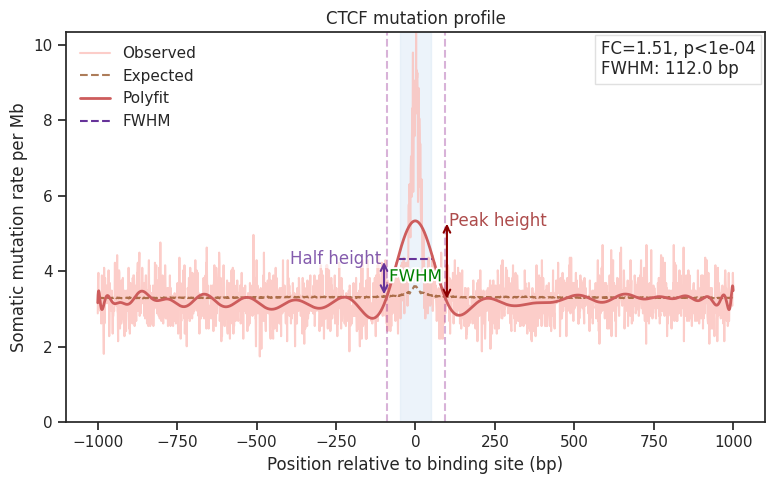

In [23]:
#Representative CTCF plot
config_rcparams()

core = 50
n_samples = 314
gene = "CTCF"

# CTCF positional mutation profile
to_plot = pos_muts[pos_muts["TFBS"] == gene].copy().sort_values("position")

# Number of CTCF binding sites
n_sites = int(site_counts.loc[site_counts["Gene"] == gene,"Length_filtered"].iloc[0])

# Mutation rate per Mb across 314 HCC samples
to_plot_normalised = to_plot.copy()
to_plot_normalised["observed_muts"] = to_plot_normalised["observed_muts"]/(n_sites*n_samples)*1e6
to_plot_normalised["expected_muts"] = to_plot_normalised["expected_muts"]/(n_sites*n_samples)*1e6

# Core FC and P value
fc_core, p_value_core = chip_stats.loc[chip_stats["Gene"] == gene,["FC_50","P-value50"]].iloc[0]

# Previously calculated FWHM information
fwhm_info = distances[distances["Gene"] == gene].iloc[0]
neg_low = fwhm_info["Neg_intersect"]
pos_low = fwhm_info["Pos_intersect"]
distance = fwhm_info["tot_dist"]
neg_halfmax_position = fwhm_info["Neg_halfmax_position"]
pos_halfmax_position = fwhm_info["Pos_halfmax_position"]
FWHM = fwhm_info["FWHM"]

# Scale half-height to mutation rate per Mb
half_max = fwhm_info["Half_height"]/n_samples*1e6

# Baseline used for half-height schematic
peak_window = to_plot_normalised[
    (to_plot_normalised["position"] >= neg_low) &
    (to_plot_normalised["position"] <= pos_low)
]
y0 = peak_window["expected_muts"].min()

#figure - mutation plot
fig, ax = plt.subplots(figsize=(8,5))

# Observed (light pink)
plt.plot(to_plot_normalised['position'], to_plot_normalised['observed_muts'],color="#fcb9b2", alpha=0.7, label="Observed")
# Expected (saddle brown dashed)
plt.plot(to_plot_normalised['position'], to_plot_normalised['expected_muts'],color="saddlebrown", linestyle="--", label="Expected", alpha=0.7)
# Highlight core region
ax.axvspan(-core, core, color="#dbe9f6", alpha=0.5)
# Polyfit
coefs = poly.polyfit(to_plot_normalised['position'],to_plot_normalised['observed_muts'], 50)
ffit = poly.polyval(to_plot_normalised['position'], coefs)

plt.plot(to_plot_normalised['position'], ffit, color="indianred", linewidth=2, zorder=3, label="Polyfit")

# Mark peak
x_offset = 100
peak_idx = int(np.argmax(ffit))
peak_x = to_plot_normalised["position"].iloc[peak_idx]
peak_y = float(ffit.iloc[peak_idx])

# Peak height: vertical arrow at x = peak_x + x_offset
x_annot = peak_x + x_offset
ax.annotate(
    "",
    xy=(x_annot, peak_y), xytext=(x_annot, 3.2),
    arrowprops=dict(arrowstyle="<->", color="darkred", lw=1.5))

ax.text(
    x_annot + 160, peak_y + 0.0001,
    "Peak height",
    rotation=0, ha="center", va="center",
    color="darkred", alpha=0.7,
    bbox=dict(facecolor="white", alpha=0.3, edgecolor="none", pad=0))

print(f'TF:{gene}, Distance: {distance}, FWHM: {FWHM}')

#schematic annotations
#Half height: vertical arrow
x_annot_half = peak_x + x_offset

ax.annotate(
    "",
    xy=(-x_annot_half, half_max), xytext=(-x_annot_half, y0),
    arrowprops=dict(arrowstyle="<->", color="rebeccapurple", lw=1.5))

ax.text(x_annot_half -350, half_max + 0.0001,
    "Half height",
    rotation=0, ha="center", va="center",
    color="rebeccapurple", alpha=0.8,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=0))

#annotate FWHM
txt = ax.text(
    (neg_halfmax_position + pos_halfmax_position)/2,
    half_max*0.95,
    "FWHM",
    ha="center", va="top", color="green")

txt.set_path_effects([
    pe.Stroke(linewidth=3, foreground="white"),pe.Normal()])

# Plot the dashed vertical lines at the instances
ax.vlines(x=neg_low, ymin=0,ymax=max(to_plot_normalised["observed_muts"]),colors='purple', alpha=0.3, linestyle='--')
ax.vlines(x=pos_low, ymin=0,ymax=max(to_plot_normalised["observed_muts"]),colors='purple', alpha=0.3, linestyle='--')
ax.hlines(y=half_max,xmin=neg_halfmax_position, xmax=pos_halfmax_position, colors='rebeccapurple', linestyle='--',label='FWHM')

#ticks
ax.tick_params(axis="y", which="both", left=True, labelleft=True)
ax.tick_params(axis="x", which="both", bottom=True, labelbottom=True)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)

# Set the y-axis limit to ensure lines cut the x-axis
ax.set_ylim(0, max(to_plot_normalised["observed_muts"]))

# Title + annotation
ax.set_title(f"{gene} mutation profile")
ax.set_xlabel("Position relative to binding site (bp)")
ax.set_ylabel("Somatic mutation rate per Mb")

label_text = (f"{format_fc_p(fc_core,p_value_core)}\n"f"FWHM: {FWHM:.1f} bp")

ax.text(0.765, 0.98, label_text, transform=ax.transAxes, ha="left", va="top", linespacing=1.15,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="lightgray"))
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
#plt.savefig(FIGURE_DIR / "Fig1B_CTCF_mutation_profile_FWHM.svg",bbox_inches='tight',format="svg",dpi=500.0)
plt.show()

### Fig1B (bottom panel): Motif-core-flank schematic

In [24]:
def plot_tfbs_schematic(flank=1000, core=50, motif=20, dhs = 250, figsize=(7,1.8)):
    
    config_rcparams()
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_xlim(-flank, flank+5)
    ax.set_ylim(-0.35,1)
    ax.axis("off")

    # colors (matching your mutation plot)
    flank_color = "#fcb9b2"
    core_color = "#dbe9f6"
    motif_color = "darkred"

    # TFBS outline
    tfbs = patches.Rectangle(
        (-flank, 0.3), 2*flank, 0.2,
        fill=False, edgecolor="black", linewidth=1)
    ax.add_patch(tfbs)

    # flanks
    ax.add_patch(
        patches.Rectangle((-flank,0.3), flank-core,0.2,
        facecolor= "white", alpha=0.8, edgecolor="salmon"))
    ax.add_patch(
        patches.Rectangle((core,0.3), flank-core,0.2,
        facecolor= "white", alpha=0.8, edgecolor="salmon")
    )
    # # dhs outline
    # ax.add_patch(
    #     patches.Rectangle((-core-180 ,0.31), 3*core,0.288,
    #     facecolor="peachpuff", edgecolor="gray")
    # )
    # ax.add_patch(
    #     patches.Rectangle((core + 30,0.31), 3*core,0.288,
    #     facecolor="peachpuff", edgecolor="gray")
    # )

    # tfbs outline
    ax.add_patch(
        patches.Rectangle((-core-80 ,0.31), 3*core,0.195,
        facecolor="floralwhite", edgecolor="gray"))
    ax.add_patch(
        patches.Rectangle((core-70,0.31), 3*core,0.195,
        facecolor="floralwhite", edgecolor="gray"))

    # core
    ax.add_patch(
        patches.Rectangle((-core-17,0.31), 2.78*core,0.195,
        facecolor=core_color, edgecolor="steelblue"))

    # motif
    ax.add_patch(
        patches.Rectangle((-motif/2,0.31), motif,0.190,
        facecolor=motif_color, alpha=0.6, edgecolor="darkred"))

    # labels
   # ax.text(0,0.08,"TFBS", ha="center")
    ax.text(0,0,"Core", ha="center", color="steelblue")
    ax.text(-flank/2,0,"Flank", ha="center", color="black")
    ax.text(flank/2,0,"Flank", ha="center", color="black")

    ax.text(-flank,0.15,f"-{flank}", ha="center")
    ax.text(-core,0.15,f"-{core}", ha="center", color="steelblue")
    ax.text(core,0.15,f"{core}", ha="center", color="steelblue")
    ax.text(0,0.6,"Motif", ha="center", color="darkred")
    ax.text(flank,0.15,f"{flank}", ha="center")
    # ax.text(-dhs,0.15,f"-{dhs}", ha="center", color = "black")
    # ax.text(dhs,0.15,f"{dhs}", ha="center", color = "black")

    # --- bracket lines under the schematic ---
    y_br = 0.05        # vertical position of the bracket line
    cap = 0.03            # height of the little vertical caps
    lw = 1.0
    
    # soft pink line color + subtle border-ish effect
    line_col = "brown"    # "#fcb9b2"
    cap_col = "brown"         # slight darker edge
    
    # Left flank bracket: [-flank, -core]
    ax.hlines(y_br, -flank/2 + 70, -core -20, colors=line_col, linewidth=lw)
    ax.hlines(y_br, -1000, -flank/2 - 75, colors=line_col, linewidth=lw)
    ax.vlines([-flank, -core-20], y_br-cap, y_br+cap, colors=cap_col, linewidth=lw)

    
    # Right flank bracket: [core, flank]
    ax.hlines(y_br, core +20, flank/2 -75, colors=line_col, linewidth=lw)
    ax.hlines(y_br, 1000, flank/2 + 70, colors=line_col, linewidth=lw)
    ax.vlines([core +20, flank], y_br-cap, y_br+cap, colors=cap_col, linewidth=lw)

    plt.tight_layout()
    return fig, ax

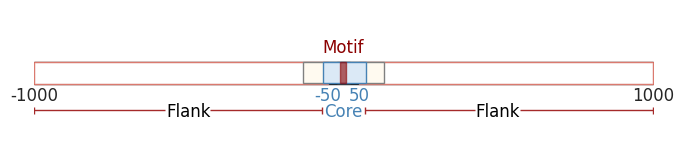

In [25]:
plot_tfbs_schematic()
#plt.savefig(FIGURE_DIR / "Fig1B_motif_core_flank_schema.svg", bbox_inches='tight',format="svg",dpi=500.0 )

### Fig1C: Core mutation enrichment across 156 TFBS

In [27]:
chip_stats.head()

,Gene,Obs_core101,Obs_flank,Exp_core101,Exp_flank,FC_50,FC_dhs(250),FC_flank,Odds Ratio,P-value50,fdr_50,fdr50_log10,log2Fc,log2OR
0,ARID3A,2184,25408,1401.878387,26190.121613,1.557910,1.105147,0.934439,1.606865,7.166796e-42,7.453468e-41,40.127642,0.639612,0.684249
1,ARID4B,3808,46433,2667.118741,47573.881259,1.427758,1.041539,0.957769,1.462877,8.326417e-49,1.298921e-47,46.886417,0.513751,0.548808
2,ARID5B,4973,66839,3731.243991,68080.756009,1.332799,1.058906,0.960882,1.357634,5.374094e-43,5.988276e-42,41.222698,0.414460,0.441095
3,ASH2L,1522,27245,1506.273090,27260.726910,1.010441,1.041066,0.987791,1.011181,7.794352e-01,7.895577e-01,0.102616,0.014985,0.016041
4,ATF1,953,13039,735.409036,13256.590964,1.295877,1.107713,0.948985,1.318177,4.885186e-08,7.189519e-08,7.143300,0.373929,0.398544


In [28]:
len(chip_stats[(chip_stats["fdr_50"] < 0.05) & (chip_stats["log2Fc"] > np.log2(1))])

137

In [29]:
len(chip_stats[(chip_stats["fdr_50"] < 0.05) & (chip_stats["log2Fc"] > np.log2(1.5))])

14

In [30]:
# label repulsion
try:
    from adjustText import adjust_text
    _HAS_ADJUSTTEXT = True
except Exception:
    _HAS_ADJUSTTEXT = False

/tmp/ipykernel_770167/2319705296.py:50: UserWarning: You passed a edgecolor/edgecolors ('brown') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  sc = ax.scatter(
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/tmp/ipykernel_770167/2319705296.py:136: UserWarning: You passed a edgecolor/edgecolors ('brown') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  h3 = ax.scatter([], [], s= 50, marker = "+", c="honeydew", edgecolors="brown", linewidths=1.7)
findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.


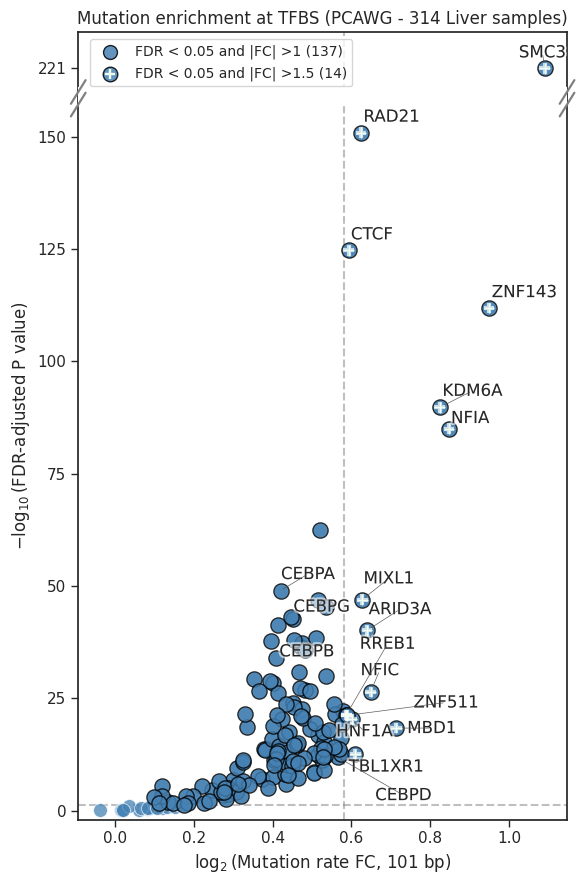

In [31]:
config_rcparams()

fig, ax = plt.subplots(figsize=(6, 9))

# thresholds
threshold = -np.log10(0.05)
fc_cut = 0.58  # ~log2(1.5)

# y-axis break parameters (single axis with compression)
y_break_low  = 160
y_break_high = 200
compress = 0.25
pad_top = 8

df = chip_stats.copy()
df["fdr50_log10"] = df["fdr50_log10"].astype(float)
df["log2Fc"] = df["log2Fc"].astype(float)

# significance flags
df["significant"] = df["fdr50_log10"] >= threshold
df["interest_fc"] = df["log2Fc"].abs() > fc_cut
df["significance"] = np.where(df["significant"], "Significant", "Not Significant")

# compressed y for plotting
df["y_plot"] = df["fdr50_log10"]
mask_hi = df["fdr50_log10"] > y_break_high
df.loc[mask_hi, "y_plot"] = y_break_low + (df.loc[mask_hi, "fdr50_log10"] - y_break_high) * compress

# base scatter (colored by significance only)
palette = {"Significant": "steelblue", "Not Significant": "steelblue"}
for key, sub in df.groupby("significance"):
    ax.scatter(
        sub["log2Fc"], sub["y_plot"],
        s= 100, c=palette[key], alpha=0.75,
        edgecolors="white", linewidths=0.6,
        zorder=2
    )

# highlight: significant
hi = df[df["significant"]]
sc = ax.scatter(
    hi["log2Fc"], hi["y_plot"],
    s= 120, c="steelblue", alpha = 0.8, 
    edgecolors="black", linewidths=1.0,
    zorder=3
)

# highlight: significant & |FC| > 1.5
hi = df[df["significant"] & df["interest_fc"]]
sc = ax.scatter(
    hi["log2Fc"], hi["y_plot"],
    s= 60, alpha = 1, 
    marker="+", c="honeydew", edgecolors = "brown", linewidths= 1,
    zorder= 4
)
sc.set_path_effects([pe.withStroke(linewidth=3, foreground="white", alpha=0.7)])

# labels (same rule as you had)
force_label_exact = {"CTCF", "NFIA"}
force_label_prefixes = ("CEBP",)

def is_forced_label(g):
    return isinstance(g, str) and (g in force_label_exact or g.startswith(force_label_prefixes))

label_mask = (df["significant"] & df["interest_fc"]) | df["Gene"].apply(is_forced_label)
lab = df[label_mask]

texts = []
for x, y, gene in zip(lab["log2Fc"], lab["y_plot"], lab["Gene"]):
    t = ax.text(x, y, gene, ha="left", va="bottom", fontsize = 12)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground="white", alpha=0.6)])
    texts.append(t)

if _HAS_ADJUSTTEXT and texts:
    adjust_text(
        texts, ax=ax,
        expand_points=(1.1, 1.2), expand_text=(1.1, 1.3),
        arrowprops=dict(arrowstyle="-", color="0.3", lw=0.5, alpha=0.9)
    )

# axes labels/title
ax.set_ylabel(r"$-\log_{10}$(FDR-adjusted P value)", fontsize = 12)
ax.set_xlabel(r"$\log_{2}$(Mutation rate FC, 101 bp)", fontsize = 12)
ax.set_title("Mutation enrichment at TFBS (PCAWG - 314 Liver samples)", fontsize = 12)

# threshold lines (NO x=0 line)
ax.axhline(threshold, color="gray", linestyle="--", zorder=1, alpha = 0.5)
ax.axvline(fc_cut,  color="gray", linestyle="--", zorder=1, alpha = 0.5)
#ax.axvline(-fc_cut, color="lightcoral", linestyle="--", zorder=1)

# --- set y limits FIRST ---
ymax = float(df["y_plot"].max())
ax.set_ylim(-2, ymax + pad_top)

#  adding a thin "gap band" ONLY at the break (not whole background) ---
# Make the band slightly thicker than the slashes so it reads as space
gap_half = 1
ax.axhspan(y_break_low - gap_half-1.8, y_break_low + gap_half,
           color="white", zorder=4)

#draw the break slashes on top of the band 
y0, y1 = ax.get_ylim()
y_break_ax = (y_break_low - y0) / (y1 - y0)

d = 0.015
gap = 0.016
kw = dict(transform=ax.transAxes, color="0.5", clip_on=False, linewidth=1.6, zorder=5)

# left slashes
ax.plot((-d, +d), (y_break_ax - d, y_break_ax + d), **kw)
ax.plot((-d, +d), (y_break_ax - d - gap, y_break_ax + d - gap), **kw)

# right slashes
ax.plot((1 - d, 1 + d), (y_break_ax - d, y_break_ax + d), **kw)
ax.plot((1 - d, 1 + d), (y_break_ax - d - gap, y_break_ax + d - gap), **kw)

# y ticks: normal ticks up to break, plus one outlier tick with REAL value
tick_step = 25
base_ticks = list(np.arange(0, y_break_low + 1e-9, tick_step))
ticks = base_ticks.copy()
ticklabels = [str(int(t)) for t in base_ticks]

imax = df["fdr50_log10"].idxmax()
y_true = float(df.loc[imax, "fdr50_log10"])
y_out_plot = float(df.loc[imax, "y_plot"])
if y_true > y_break_high:
    ticks.append(y_out_plot)
    ticklabels.append(str(int(round(y_true))))

ax.set_yticks(ticks)
ax.set_yticklabels(ticklabels)

# legend 
h1 = ax.scatter([], [], s= 100, c="steelblue", alpha=0.85, edgecolors="black", linewidths = 1)
h2 = ax.scatter([], [], s= 110, c="steelblue", alpha=0.85, edgecolors="black", linewidths= 1)
h3 = ax.scatter([], [], s= 50, marker = "+", c="honeydew", edgecolors="brown", linewidths=1.7)

ax.legend(
    [h1, (h2, h3)],
    [r"FDR < 0.05 and |FC| >1 (137)",
    r"FDR < 0.05 and |FC| >1.5 (14)"],
    loc="upper left", fontsize = 10, bbox_to_anchor=(0.01, 1),
    frameon=True
)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.tick_params(axis="both",which="major",bottom=True,left=True,length=5,width=1,direction="out")
#plt.savefig(FIGURE_DIR / "Fig1C_FC_vs_pvalue_314PCAWG.svg", bbox_inches='tight',format="svg",dpi=500.0 )
plt.tight_layout()
plt.show()

### Fig1D: Mutation enrichment across TFBS Motif-core-DHS-Flank regions

In [71]:
# Core/DHS/flank values from ChIP-centred TFBS analysis
plot_df = (chip_stats[chip_stats["Gene"].isin(TFs_sig)][["Gene","FC_50","FC_dhs(250)","FC_flank", "fdr_50"]].copy())

# Motif FC where a mapped motif is available
plot_df = plot_df.merge(motif_stats[["Gene","FC_motif", "fdr_motif"]],on="Gene",how="left")


In [72]:
threshold = -np.log10(0.05)

# Motif significance
plot_df["significance_motif"] = np.where(plot_df["fdr_motif"].isna(),"NA",
    np.where(plot_df["fdr_motif"] <= 0.05,"Significant","Not Significant"))

# Core significance
plot_df["significance_core"] = np.where(plot_df["fdr_50"] <= 0.05,"Significant","Not Significant")

As CEBPs are enriched at only the motifs

In [73]:
cebps = {"CEBPA","CEBPB","CEBPG"}

mapped_tf_names = set(mapped_motifs["Gene"].unique())

plot_df["group"] = np.select([plot_df["Gene"].isin(cebps),
  plot_df["Gene"].isin(mapped_tf_names) & (plot_df["fdr_motif"] <= 0.05),
  plot_df["Gene"].isin(mapped_tf_names) & (plot_df["fdr_motif"] > 0.05)],
 ["Motif","Motif + Core","Core-only (motif ns)" ],
 default="Core-only (no motif)")

In [74]:
core_dhs_flank = plot_df.melt(
    id_vars=["Gene","group"],
    value_vars=["FC_motif","FC_50","FC_dhs(250)","FC_flank"],
    var_name="annot",value_name="obs/exp")

core_dhs_flank["annot"] = core_dhs_flank["annot"].replace({"FC_motif":"Motif",
    "FC_50":"Core","FC_dhs(250)":"DHS","FC_flank":"Flank"})

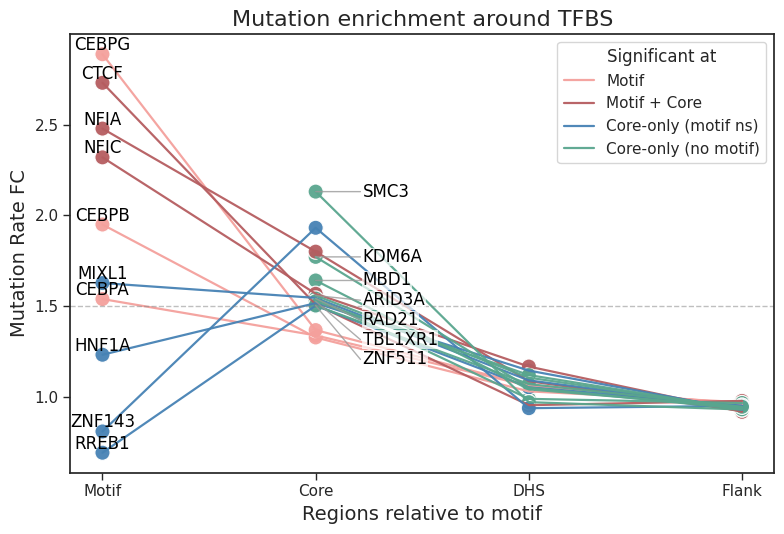

In [76]:
config_rcparams()

# keep only rows with valid values
df = core_dhs_flank[core_dhs_flank["obs/exp"].notna()].copy()

# ordered categories
annot_order = ["Motif", "Core", "DHS", "Flank"]
df["annot"] = pd.Categorical(df["annot"], categories=annot_order, ordered=True)

# palette aligned with previous figures
palette = {
    "Motif + Core": "#b55d60",          # muted brick red
    "Motif": "#f4a09c",                 # soft salmon
    "Core-only (motif ns)": "steelblue",  # medium soft blue
    #"Core-only (no motif)": "#8c78b3", 
    "Core-only (no motif)": "#59A68E",  #light blue family as core box
    "NS/Other": "#b0b0b0"
}

fig, ax = plt.subplots(figsize=(8,5.5))

# lines for each gene
sns.lineplot(
    data=df,
    x="annot", y="obs/exp",
    hue="group", units="Gene", estimator=None,
    linewidth=1.6, palette=palette, alpha = 0.95,
    ax=ax, legend=True
)

# points
sns.scatterplot(
    data=df,
    x="annot", y="obs/exp",
    hue="group", palette=palette,
    s=120, ax=ax, legend=False, alpha = 0.95
)

# map annotation categories to x positions
xpos_map = {name: i for i, name in enumerate(annot_order)}

# decide where to label each gene
motif_label_rows = []
core_label_rows = []

for gene in df["Gene"].unique():
    gene_data = df[df["Gene"] == gene]
    if "Motif" in gene_data["annot"].values:
        motif_label_rows.append(gene_data[gene_data["annot"] == "Motif"].iloc[0])
    elif "Core" in gene_data["annot"].values:
        core_label_rows.append(gene_data[gene_data["annot"] == "Core"].iloc[0])

# label motif genes directly
for row in motif_label_rows:
    ax.text(
        xpos_map[row["annot"]], row["obs/exp"], row["Gene"],
        va="bottom", ha="center", color="black", zorder=5
    )

# label core-only genes with offset + connector
if core_label_rows:
    core_label_rows = sorted(core_label_rows, key=lambda r: r["obs/exp"])

    x_core = xpos_map["Core"]
    x_text = x_core + 0.22

    y_points = np.array([float(row["obs/exp"]) for row in core_label_rows])

    # minimum vertical gap between neighboring labels
    y_min, y_max = ax.get_ylim()
    yr = y_max - y_min
    min_gap = 0.045 * yr   # increase to 0.055 if still crowded

    # start from true y positions
    y_texts = y_points.copy()

    # forward pass: push labels upward if too close
    for i in range(1, len(y_texts)):
        if y_texts[i] - y_texts[i-1] < min_gap:
            y_texts[i] = y_texts[i-1] + min_gap

    # # optional backward pass: if top labels go too high, shift downward
    # overflow = y_texts[-1] - (y_max - 0.03 * yr)
    # if overflow > 0:
    #     y_texts = y_texts - overflow

        # recheck from bottom so labels still don't collide
        for i in range(len(y_texts)-2, -1, -1):
            if y_texts[i+1] - y_texts[i] < min_gap:
                y_texts[i] = y_texts[i+1] - min_gap

    for row, y_text in zip(core_label_rows, y_texts):
        y_point = float(row["obs/exp"])

        ax.text(
            x_text, y_text, row["Gene"],
            va="center", ha="left", color="black", zorder=6, fontsize = 12,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.2)
        )

        ax.annotate(
            "",
            xy=(x_core, y_point), xycoords="data",
            xytext=(x_text - 0.01, y_text), textcoords="data",
            arrowprops=dict(
                arrowstyle="-",
                color="0.6",
                lw=1.0,
                alpha=0.8,
                shrinkA=0, shrinkB=0
            ),
            zorder=4
        )

ax.set_xlabel("Regions relative to motif", fontsize =14)
ax.set_ylabel("Mutation Rate FC", fontsize = 14)
ax.set_title("Mutation enrichment around TFBS", fontsize = 16)
ax.axhline(1.5, ls="--", lw=1, color="grey", alpha=0.5)


ax.legend(title="Significant at", loc="upper right", frameon=True)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.tick_params(axis="both",which="major",bottom=True,left=True,length=5,width=1,direction="out")

plt.tight_layout()
#ax.set_ylim(0.5,3)
#plt.savefig(FIGURE_DIR / "Fig1D_Motif_core_dhs_flank.svg", bbox_inches='tight',format="svg",dpi=500.0 )
plt.show()

### Fig1E-G: TFBS motif-centered SBS excess and sequence logo

Observed and expected mutations were aggregated across motif-centered windows. Expected counts were estimated from local trinucleotide mutation probabilities and scaled within each motif window to match the total number of observed mutations in that window. Excess mutation abundance was calculated as observed minus expected.

In [93]:
TF_motifs = mapped_motifs[mapped_motifs["Gene"].isin(TFs_sig)].copy()
TF_motifs.reset_index(drop=True,inplace=True)

print(len(TF_motifs))
print(TF_motifs["Gene"].nunique())
TF_motifs.head()

124298
10


,Chr,Motif_start,Motif_end,Score,Strand,motif_len,Pfm,Gene
0,chr1,1243613,1243624,6.086335,-,11,CEBPA_023.pfm,CEBPA
1,chr1,1243614,1243625,7.500603,+,11,CEBPA_023.pfm,CEBPA
2,chr1,1333735,1333746,7.118479,+,11,CEBPA_023.pfm,CEBPA
3,chr1,1512958,1512969,6.642196,-,11,CEBPA_023.pfm,CEBPA
4,chr1,1522659,1522670,6.496677,-,11,CEBPA_023.pfm,CEBPA


In [94]:
SBS_TYPES = ("T-G", "T-C", "T-A", "C-T", "C-G", "C-A")
COLOR_BY_MUT = {
    "T-G": "#FCECD4",
    #"T-C": "#879A7D",
    "T-A": "#A1BEED", 
    #"C-T": "#CC7C80",
    "C-G": "#726EC0",
    "C-A": "#5A878A",
    "C-T": "#EBB1A2",
    "T-C":"#CC7C80"}

LOGO_COLORS = {
    "A": "#5E9C7A",
    "C": "#7EA7E8",
    "G": "#E7B07A",
    "T": "#D48C8C",}

comp = str.maketrans("ACGTacgt", "TGCAtgca")
bases = ["A", "C", "G", "T"]
base_index = {"A": 0, "C": 1, "G": 2, "T": 3}

In [95]:
def revcomp(seq):
    return seq.upper()[::-1].translate(comp)


def get_profile_for_plot(profiles, tf, treatment, flank=20):
    cols = [f"excess_{sbs}" for sbs in SBS_TYPES] + ["excess_total"]

    df = profiles[(profiles["TFBS"] == tf) & (profiles["treatment"] == treatment)].copy()

    df = (df.groupby("position", as_index=False)[cols].sum().sort_values("position"))

    df = df[(df["position"] >= -flank) & (df["position"] <= flank)].copy()
    return df


In [96]:
def fetch_centered_window_sequences(df_motifs, flank=20):
    """
    Fetch motif-centered windows of length 2*flank+1.
    Reverse-complement negative-strand sites so all sequences are aligned in motif space.
    """
    seqs = []

    for _,row in df_motifs.iterrows():
        chrom = str(row["Chr"])
        start = int(row["Motif_start"])
        end = int(row["Motif_end"])
        strand = str(row["Strand"])

        center = (start+end)//2
        win_start = center-flank
        win_end = center+flank+1  # end-exclusive

        if win_start < 0:
            continue

        try:
            seq = genome[chrom][win_start:win_end].seq.upper()
        except Exception:
            continue

        if len(seq) != 2 * flank + 1:
            continue
        if any(b not in "ACGT" for b in seq):
            continue

        if strand == "-":
            seq = revcomp(seq)

        seqs.append(seq)

    return seqs


In [97]:
def make_logo_df_from_seqs(seqs):
    """
    Convert equal-length sequences into position-frequency dataframe for logomaker.
    """
    if len(seqs) == 0:
        return None

    L = len(seqs[0])
    mat = np.zeros((4, L), dtype=float)

    for s in seqs:
        if len(s) != L:
            continue
        for i, base in enumerate(s):
            if base in base_index:
                mat[base_index[base], i] += 1

    col_sums = mat.sum(axis=0, keepdims=True)
    col_sums[col_sums == 0] = 1
    mat = mat / col_sums

    center = L // 2
    df_logo = pd.DataFrame(mat.T, columns=bases)
    df_logo["position"] = np.arange(L) - center
    return df_logo.set_index("position")

In [106]:

def plot_excess_with_logo( profiles, TF_motifs, tf, treatment, flank=20,
    show_total=True,total_style="line",      # "line", "fill", "line+fill", or None
    show_motif_bounds=True, figsize=(10, 5.5)):
    """
    Top: stacked bar plot of excess mutations by SBS class
    Bottom: sequence logo across motif-centered +/- flank window

    Inputs required
    ------
    profiles : dataframe with excess_* columns and columns TFBS, treatment, position
    TF_motifs: dataframe with motif windows
    tf       : TF name
    treatment: motif/PFM label for TFs with multiple pfms if we choose them
    """

    # mutation profile
    prof = get_profile_for_plot(profiles, tf=tf, treatment=treatment, flank=flank)
    if prof.empty:
        raise ValueError(f"No profile rows found for tf={tf}, treatment={treatment}")

    x = prof["position"].to_numpy()

    # motif subset for sequence logo
    motifs_sub = TF_motifs[(TF_motifs["Gene"] == tf) &(TF_motifs["Pfm"] == treatment)].copy()

    if motifs_sub.empty:
        raise ValueError(f"No motif rows found for tf={tf}, treatment={treatment}")

    seqs = fetch_centered_window_sequences(motifs_sub, flank=flank)
    df_logo = make_logo_df_from_seqs(seqs)

    # motif length from column 3
    motif_len = int(round(motifs_sub["motif_len"].median()))
    motif_half = motif_len // 2

    # figure
    fig, (ax1, ax2) = plt.subplots(2, 1,figsize=figsize,
        sharex=True,gridspec_kw={"height_ratios": [3.2, 1.15], "hspace": 0.05})

    # -------------------------
    # stacked bars
    # -------------------------
    bottom_pos = np.zeros_like(x, dtype=float)
    bottom_neg = np.zeros_like(x, dtype=float)

    for sbs in SBS_TYPES:
        y = prof[f"excess_{sbs}"].to_numpy()

        y_pos = np.where(y > 0, y, 0)
        y_neg = np.where(y < 0, y, 0)

        ax1.bar(x,y_pos,bottom=bottom_pos,
            width= 1,color=COLOR_BY_MUT[sbs],
            edgecolor= "grey",linewidth= 1,alpha=0.8,
            label=sbs,zorder=2)
        ax1.bar(
            x,y_neg,bottom=bottom_neg,
            width= 1,color=COLOR_BY_MUT[sbs],
            edgecolor= "grey",linewidth= 1,
            alpha=0.8,zorder=2)

        bottom_pos += y_pos
        bottom_neg += y_neg

    # y-limits from true stacked values
    excess_cols = [f"excess_{sbs}" for sbs in SBS_TYPES]
    Y = prof[excess_cols].to_numpy()
    
    stacked_pos = np.where(Y > 0, Y, 0).sum(axis=1)
    stacked_neg = np.where(Y < 0, Y, 0).sum(axis=1)
    
    ymax = stacked_pos.max() + 10
    ymin = stacked_neg.min() - 10
    
    ax1.set_ylim(ymin, ymax)

    # motif bounds as faint dotted guides
    if show_motif_bounds and motif_len > 0:
        for ax in (ax1, ax2):
            ax.axvline(-motif_half - 0.5, color="0.82", lw=0.7, ls=":")
            ax.axvline(motif_half + 0.5, color="0.82", lw=0.7, ls=":")

    ax1.axhline(0, color="0.30", lw=0.8)
    ax1.axvline(0, color="0.55", lw=0.8, ls="--")

    ax1.set_ylabel("Excess mutations")
    ax1.set_title(f"{tf} motif", pad=2)

    ax1.legend(
        frameon=True,ncol=3,fontsize=7,
        handlelength=1.2,columnspacing=1.0,loc="upper right")
    
    #logo
    if df_logo is not None:
        logo = logomaker.Logo(
            df_logo,ax=ax2,color_scheme=LOGO_COLORS,
            baseline_width=0,vpad=0.02,width=0.95)

        ax2.axvline(0, color="0.50", lw=0.8, ls="--")
        ax2.set_ylabel("Freq")
    else:
        ax2.text(
            0.5, 0.5, "No valid sequences",
            ha="center", va="center", transform=ax2.transAxes
        )
        ax2.set_axis_off()

    # asthetics
    ax2.set_xlabel("Position relative to motif center (bp)")
    
    # shared limits
    for ax in (ax1, ax2):
        ax.set_xlim(-flank - 0.5, flank + 0.5)
    
    # --- mutation panel (top) ---
    ax1.spines["top"].set_visible(True)
    ax1.spines["right"].set_visible(True)
    ax1.spines["left"].set_visible(True)
    
    # this becomes the divider line
    ax1.spines["bottom"].set_visible(True)
    ax1.spines["bottom"].set_color("0.7")
    ax1.spines["bottom"].set_linewidth(0.8)

    ax1.tick_params(axis="both",which="major",bottom=True,left=True,length=5,width=1,direction="out")
    
    # --- logo panel (bottom) ---
    ax2.spines["top"].set_visible(False)   # avoid double separator
    ax2.spines["right"].set_visible(True)
    ax2.spines["left"].set_visible(True)
    ax2.spines["bottom"].set_visible(True)
    print(sum(bottom_neg))
    print(sum(bottom_pos))

    panel_names = {
    "CTCF":"Fig1E",
    "CEBPB":"Fig1F",
    "NFIA":"Fig1G"}
    panel = panel_names.get(tf,tf)
    
    plt.tight_layout()
    #plt.savefig(FIGURE_DIR / f"{panel}_{tf}_SBS_excess_logo.svg",bbox_inches='tight',format="svg",dpi=500.0)

    plt.show()

-314.4981355486813
452.3063963824482


/tmp/ipykernel_770167/760973819.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


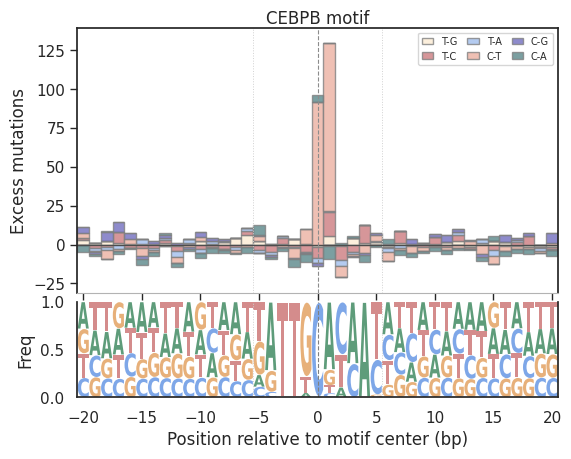

In [107]:
plot_excess_with_logo(profiles=profiles,
    TF_motifs= TF_motifs,
    tf="CEBPB", treatment="CEBPB_661.pfm",
    flank=20,show_total=True,
    total_style="line",  
    show_motif_bounds=True,figsize=(6.2, 4.8),)

-1157.5856662548895
2706.3364432261505


/tmp/ipykernel_770167/760973819.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


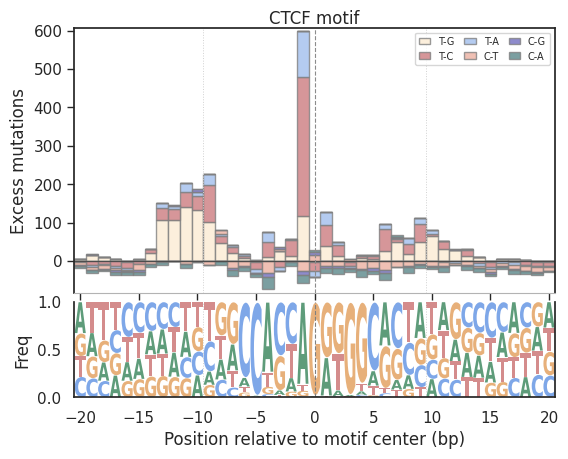

In [108]:
plot_excess_with_logo(profiles=profiles,
    TF_motifs= TF_motifs,
    tf="CTCF", treatment="CTCF_391.pfm",
    flank=20,show_total=True,
    total_style="line", 
    show_motif_bounds=True,figsize=(6.2, 4.8),)

-199.39152462737192
324.4862922047951


/tmp/ipykernel_770167/760973819.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


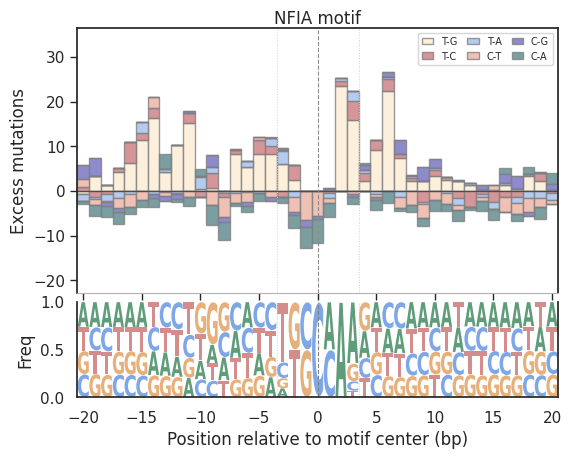

In [109]:
plot_excess_with_logo(profiles=profiles,
    TF_motifs= TF_motifs,
    tf="NFIA", treatment="NFIA_702.pfm",
    flank=20,show_total=True,
    total_style="line", 
    show_motif_bounds=True,figsize=(6.2, 4.8),)